# Step 0 — Setup and folders

In [1]:
import os
import copy
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["JULIA_NUM_THREADS"] = "4"
os.environ["PYTHON"] = "python"

from pysr import PySRRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.utils import resample
from scipy.stats import spearmanr

np.random.seed(42)

folders = [
    "results",
    "results/bootstrap",
    "results/noise",
    "results/ablation_features",
    "results/ablation_ell",
    "results/ablation_operators",
    "results/baselines",
    "results/interpretability",
    "results/robustness",
    "figures",
    "figures_AA",
    "models",
    "models/bootstrap",
    "models/robustness",
]

for f in folders:
    os.makedirs(f, exist_ok=True)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# Section 1 — Load existing data and models

In [2]:
required_files = [
    "cmb_spectra_data.npz",
    "camb_spectra_scaler.pkl",
    "pysr_restricted_model_n_s.pkl",
    "pysr_restricted_model_log_As.pkl",
    "pysr_restricted_model_omega_cdm.pkl",
    "pysr_restricted_model_tau.pkl",
    "pysr_full_model_omega_b.pkl",
    "pysr_restricted_model_omega_b_engineered.pkl",
    "omega_b_feature_scaler.pkl",
]

for f in required_files:
    print(f"{f:55s}", os.path.exists(f))

cmb_spectra_data.npz                                    True
camb_spectra_scaler.pkl                                 True
pysr_restricted_model_n_s.pkl                           True
pysr_restricted_model_log_As.pkl                        True
pysr_restricted_model_omega_cdm.pkl                     True
pysr_restricted_model_tau.pkl                           True
pysr_full_model_omega_b.pkl                             True
pysr_restricted_model_omega_b_engineered.pkl            True
omega_b_feature_scaler.pkl                              True


In [3]:
data = np.load("cmb_spectra_data.npz", allow_pickle=True)

X = data["X"]
y = data["y"]
ell_truncate = int(data["ell_truncate"])

ELL = X.shape[1] // 3

X_train_raw, X_test_raw, y_train_all, y_test_all = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

y_train_ns, y_test_ns = y_train_all[:, 0], y_test_all[:, 0]
y_train_log_As, y_test_log_As = y_train_all[:, 1], y_test_all[:, 1]
y_train_omega_b, y_test_omega_b = y_train_all[:, 2], y_test_all[:, 2]
y_train_omega_cdm, y_test_omega_cdm = y_train_all[:, 3], y_test_all[:, 3]
y_train_tau, y_test_tau = y_train_all[:, 4], y_test_all[:, 4]

targets_train = {
    "n_s": y_train_ns,
    "log_As": y_train_log_As,
    "omega_b": y_train_omega_b,
    "omega_cdm": y_train_omega_cdm,
    "tau": y_train_tau,
}

targets_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_b": y_test_omega_b,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

restricted_params = ["n_s", "log_As", "omega_cdm", "tau"]
all_params = ["n_s", "log_As", "omega_b", "omega_cdm", "tau"]

print("X:", X.shape)
print("Train:", X_train_scaled.shape)
print("Test:", X_test_scaled.shape)

X: (2000, 3000)
Train: (1600, 3000)
Test: (400, 3000)


In [4]:
X_train_raw
X_test_raw
X_train_scaled
X_test_scaled

array([[-0.24507124, -0.34736412, -0.44376474, ..., -0.9222997 ,
        -0.90379911, -0.88528424],
       [-0.14389916, -0.10778161, -0.06900764, ..., -0.20285197,
        -0.20821913, -0.21352559],
       [-0.72193967, -0.7311205 , -0.74078468, ..., -0.25172969,
        -0.25248317, -0.25320924],
       ...,
       [-0.24550953, -0.17984845, -0.11863   , ..., -0.34490359,
        -0.36621753, -0.38728673],
       [-0.60621774, -0.63855286, -0.65552622, ..., -0.90271044,
        -0.89116931, -0.87958056],
       [-0.99472447, -0.96086343, -0.94123225, ..., -0.74947861,
        -0.76434202, -0.77896081]], shape=(400, 3000))

# Section 2 — Helper functions

In [5]:
def idx_to_name(i):
    i = int(i)
    if i < ELL:
        return f"TT_l{i}"
    elif i < 2 * ELL:
        return f"TE_l{i - ELL}"
    else:
        return f"EE_l{i - 2 * ELL}"

def idx_to_name_latex(i):
    i = int(i)
    if i < ELL:
        return rf"\mathrm{{TT}}_{{\ell={i}}}"
    elif i < 2 * ELL:
        return rf"\mathrm{{TE}}_{{\ell={i - ELL}}}"
    else:
        return rf"\mathrm{{EE}}_{{\ell={i - 2 * ELL}}}"

def pretty_equation(eq_str):
    return re.sub(r"x(\d+)", lambda m: idx_to_name(m.group(1)), eq_str)

def latex_equation(eq_str):
    eq = re.sub(r"x(\d+)", lambda m: idx_to_name_latex(m.group(1)), eq_str)
    eq = eq.replace("*", r" \cdot ")
    return eq

def evaluate_model(model, Xtest, ytest):
    pred = model.predict(Xtest)
    return {
        "R2": r2_score(ytest, pred),
        "MAE": mean_absolute_error(ytest, pred),
        "pred": pred,
    }

# Section 3 — Load baseline SR models and reproduce current paper table

In [6]:
models_restricted = {
    p: joblib.load(f"pysr_restricted_model_{p}.pkl")
    for p in restricted_params
}

models_full = {
    p: joblib.load(f"pysr_full_model_{p}.pkl")
    for p in all_params
}

model_ob = joblib.load("pysr_restricted_model_omega_b_engineered.pkl")
sc_b = joblib.load("omega_b_feature_scaler.pkl")

In [7]:
TT = X[:, :ELL]

def band_avg(tt, ell0, w=5):
    lo = max(ell0 - w, 0)
    hi = min(ell0 + w + 1, tt.shape[1])
    return tt[:, lo:hi].mean(axis=1)

p1 = band_avg(TT, 220, w=5)
p2 = band_avg(TT, 540, w=5)
p3 = band_avg(TT, 800, w=5)

eps = 1e-12

Xb = np.column_stack([
    p1, p2, p3,
    p1 / (p2 + eps),
    p1 / (p3 + eps),
    p2 / (p3 + eps),
    (p1 - p2) / (p1 + p2 + eps),
    (p1 - p3) / (p1 + p3 + eps),
])

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, y[:, 2], test_size=0.2, random_state=42
)

Xb_train_scaled = sc_b.transform(Xb_train)
Xb_test_scaled = sc_b.transform(Xb_test)

# Block 1 — Bootstrap uncertainty

In [8]:
bootstrap_kwargs = {
    "niterations": 120,
    "binary_operators": ["+", "-", "*", "/"],
    "unary_operators": ["log", "sqrt"],
    "elementwise_loss": "L2DistLoss()",
    "model_selection": "best",
    "maxsize": 18,
    "precision": 32,
    "timeout_in_seconds": 1800,
    "parallelism": "multithreading",
    "verbosity": 0,
}

N_BOOT = 20
rng = np.random.default_rng(42)

uq_results = []

for param in restricted_params:
    print(f"\nBootstrap UQ for {param}")
    y_train = targets_train[param]
    y_test = targets_test[param]

    preds = []

    for b in range(N_BOOT):
        print(f"  Bootstrap {b+1}/{N_BOOT}")

        idx = rng.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)

        model = PySRRegressor(
            random_state=1000 + b,
            **bootstrap_kwargs
        )

        model.fit(X_train_scaled[idx], y_train[idx])
        pred = model.predict(X_test_scaled)
        preds.append(pred)

        joblib.dump(model, f"models/bootstrap/bootstrap_{param}_{b}.pkl")

    preds = np.array(preds)
    pred_mean = preds.mean(axis=0)
    pred_std = preds.std(axis=0)

    uq_results.append({
        "parameter": param,
        "N_bootstrap": N_BOOT,
        "R2_mean_prediction": r2_score(y_test, pred_mean),
        "MAE_mean_prediction": mean_absolute_error(y_test, pred_mean),
        "mean_pred_std": pred_std.mean(),
        "coverage_1sigma": np.mean(np.abs(y_test - pred_mean) <= pred_std),
        "coverage_2sigma": np.mean(np.abs(y_test - pred_mean) <= 2 * pred_std),
    })

    np.savez(
        f"results/bootstrap/bootstrap_predictions_{param}.npz",
        y_true=y_test,
        preds=preds,
        pred_mean=pred_mean,
        pred_std=pred_std,
    )

uq_df = pd.DataFrame(uq_results)
uq_df.to_csv("results/bootstrap/bootstrap_uq_summary.csv", index=False)
print(uq_df)


Bootstrap UQ for n_s
  Bootstrap 1/20


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  Bootstrap 2/20


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  Bootstrap 3/20


...

  Bootstrap 19/20


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  Bootstrap 20/20


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


   parameter  N_bootstrap  R2_mean_prediction  MAE_mean_prediction  \
0        n_s           20            0.994161             0.001054   
1     log_As           20            0.998440             0.002665   
2  omega_cdm           20            0.999284             0.000181   
3        tau           20            0.998704             0.000416   

   mean_pred_std  coverage_1sigma  coverage_2sigma  
0       0.001162           0.6075           0.9825  
1       0.003229           0.6500           0.9375  
2       0.000372           0.8800           1.0000  
3       0.000729           0.8150           0.9975  


# Block 2 — Calibration

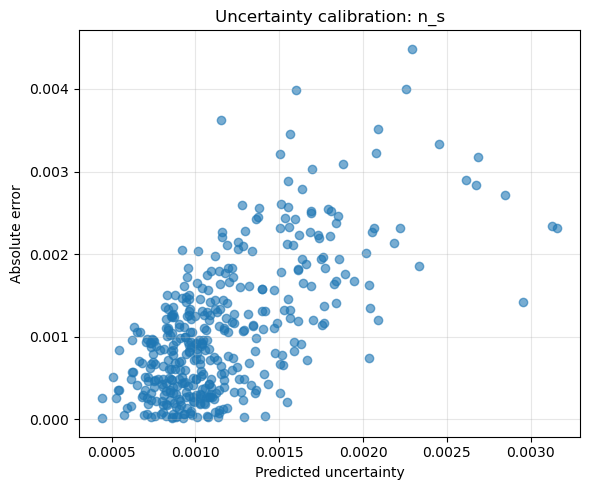

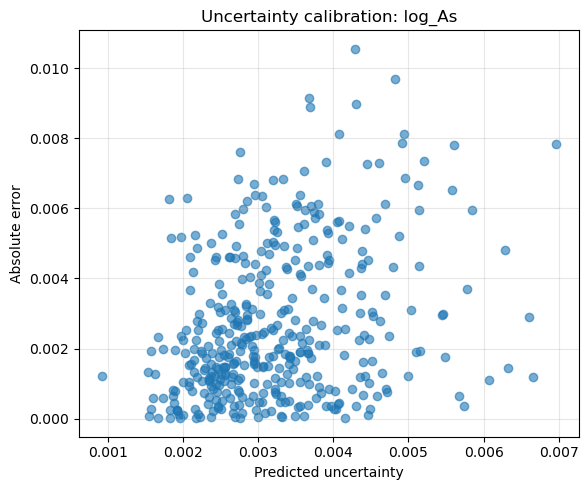

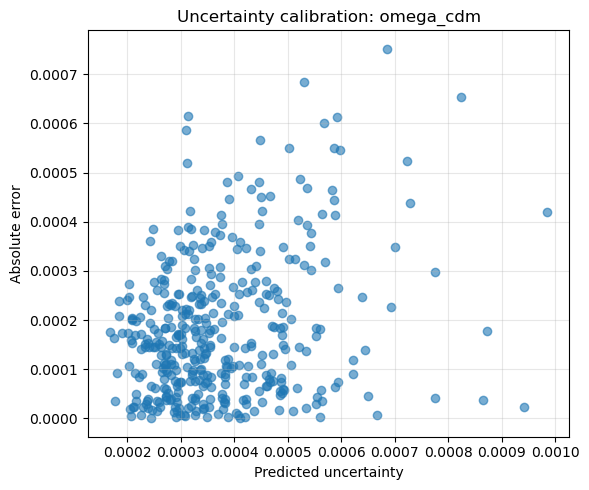

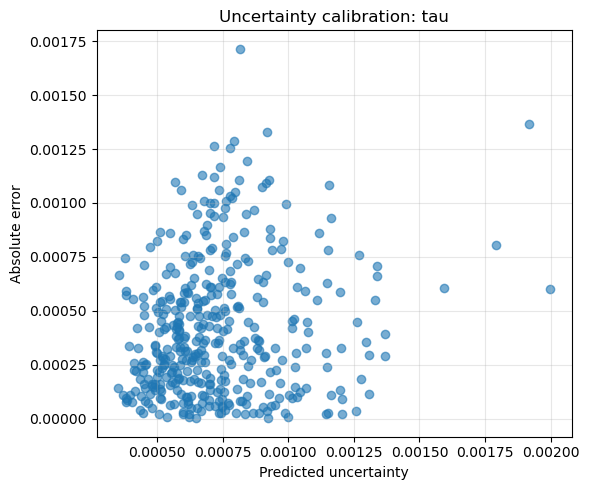

   parameter  spearman_uncertainty_error       p_value  mean_abs_error  \
0        n_s                    0.568460  1.297551e-35        0.001054   
1     log_As                    0.293712  2.118696e-09        0.002665   
2  omega_cdm                    0.176894  3.781591e-04        0.000181   
3        tau                    0.143080  4.138571e-03        0.000416   

   mean_pred_std  
0       0.001162  
1       0.003229  
2       0.000372  
3       0.000729  


In [9]:
calibration_rows = []

for param in restricted_params:
    data = np.load(f"results/bootstrap/bootstrap_predictions_{param}.npz")

    y_true = data["y_true"]
    pred_mean = data["pred_mean"]
    pred_std = data["pred_std"]

    abs_error = np.abs(y_true - pred_mean)
    rho, pval = spearmanr(pred_std, abs_error)

    calibration_rows.append({
        "parameter": param,
        "spearman_uncertainty_error": rho,
        "p_value": pval,
        "mean_abs_error": abs_error.mean(),
        "mean_pred_std": pred_std.mean(),
    })

    plt.figure(figsize=(6, 5))
    plt.scatter(pred_std, abs_error, alpha=0.6)
    plt.xlabel("Predicted uncertainty")
    plt.ylabel("Absolute error")
    plt.title(f"Uncertainty calibration: {param}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"figures_AA/calibration_{param}.pdf", bbox_inches="tight")
    plt.show()

calibration_df = pd.DataFrame(calibration_rows)
calibration_df.to_csv("results/bootstrap/calibration_summary.csv", index=False)
print(calibration_df)

# Block 3 — Predicted vs true with uncertainty bars

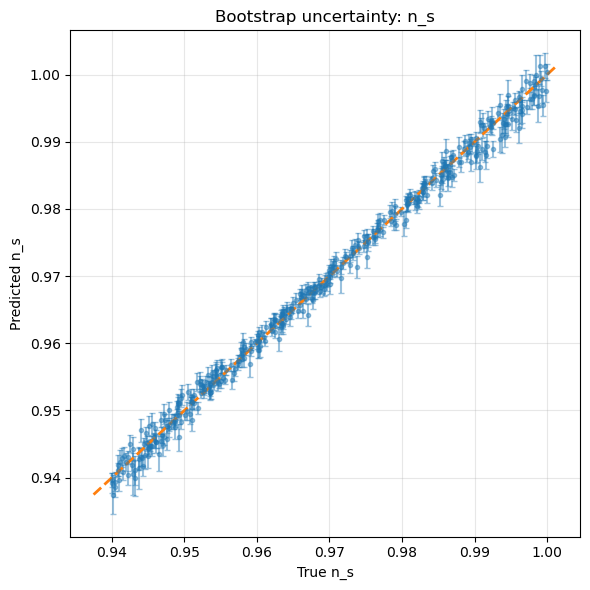

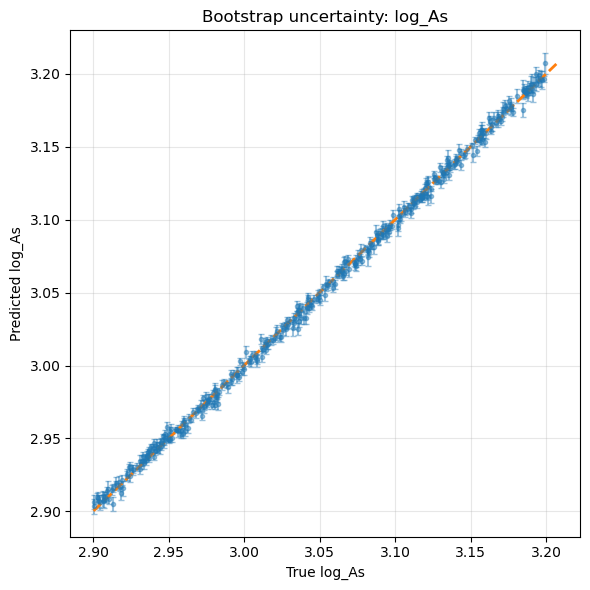

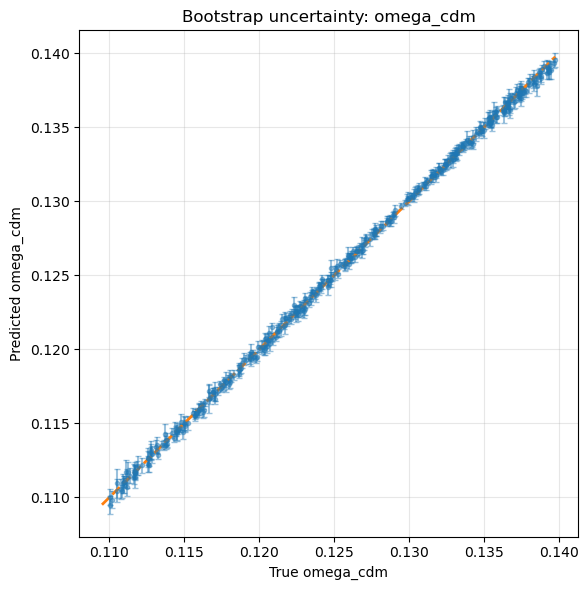

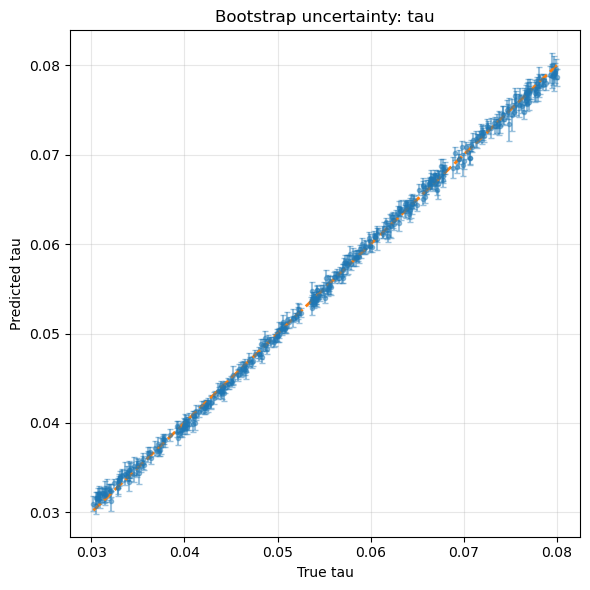

In [10]:
for param in restricted_params:
    data = np.load(f"results/bootstrap/bootstrap_predictions_{param}.npz")

    y_true = data["y_true"]
    pred_mean = data["pred_mean"]
    pred_std = data["pred_std"]

    order = np.argsort(y_true)

    plt.figure(figsize=(6, 6))
    plt.errorbar(
        y_true[order],
        pred_mean[order],
        yerr=pred_std[order],
        fmt="o",
        alpha=0.45,
        markersize=3,
        capsize=2,
    )

    min_val = min(y_true.min(), pred_mean.min())
    max_val = max(y_true.max(), pred_mean.max())
    plt.plot([min_val, max_val], [min_val, max_val], "--", lw=2)

    plt.xlabel(f"True {param}")
    plt.ylabel(f"Predicted {param}")
    plt.title(f"Bootstrap uncertainty: {param}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"figures_AA/bootstrap_pred_vs_true_{param}.pdf", bbox_inches="tight")
    plt.show()

# Block 4 — Noise robustness

In [13]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from pysr import PySRRegressor

ells = np.arange(2, 2 + ELL)

def add_fractional_cosmic_variance_noise(X_input, noise_scale=1.0, seed=42):
    rng = np.random.default_rng(seed)
    X_noisy = X_input.copy()

    for block in range(3):
        start = block * ELL
        end = (block + 1) * ELL

        spectra = X_input[:, start:end]
        frac_sigma = noise_scale * np.sqrt(2.0 / (2 * ells + 1))

        noise = rng.normal(
            loc=0.0,
            scale=np.abs(spectra) * frac_sigma,
            size=spectra.shape
        )

        X_noisy[:, start:end] = spectra + noise

    return X_noisy


def safe_regression_metrics(y_true, y_pred):
    """
    Compute R2 and MAE only on finite predictions.
    Also return invalid prediction fraction.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    finite_mask = np.isfinite(y_pred)

    invalid_fraction = 1.0 - np.mean(finite_mask)

    if finite_mask.sum() < 5:
        return {
            "R2": np.nan,
            "MAE": np.nan,
            "invalid_fraction": invalid_fraction,
            "n_valid": int(finite_mask.sum()),
            "n_total": len(y_true),
        }

    return {
        "R2": r2_score(y_true[finite_mask], y_pred[finite_mask]),
        "MAE": mean_absolute_error(y_true[finite_mask], y_pred[finite_mask]),
        "invalid_fraction": invalid_fraction,
        "n_valid": int(finite_mask.sum()),
        "n_total": len(y_true),
    }

In [14]:
noise_levels = [0.25, 0.5, 1.0, 2.0]

noise_kwargs = {
    "niterations": 100,
    "binary_operators": ["+", "-", "*", "/"],
    "unary_operators": ["log", "sqrt"],
    "elementwise_loss": "L2DistLoss()",
    "model_selection": "best",
    "maxsize": 18,
    "precision": 32,
    "timeout_in_seconds": 1800,
    "parallelism": "multithreading",
    "verbosity": 0,
}

noise_results = []

for noise_scale in noise_levels:
    print(f"\nNoise scale = {noise_scale}")

    X_train_noisy = add_fractional_cosmic_variance_noise(
        X_train_raw, noise_scale=noise_scale, seed=100
    )
    X_test_noisy = add_fractional_cosmic_variance_noise(
        X_test_raw, noise_scale=noise_scale, seed=200
    )

    scaler_clean = StandardScaler()
    Xtr_clean_scaled = scaler_clean.fit_transform(X_train_raw)
    Xte_noisy_scaled_from_clean = scaler_clean.transform(X_test_noisy)

    scaler_noisy = StandardScaler()
    Xtr_noisy_scaled = scaler_noisy.fit_transform(X_train_noisy)
    Xte_noisy_scaled = scaler_noisy.transform(X_test_noisy)

    for param in restricted_params:
        print(f"  {param}")

        # -------------------------------
        # Case 1: clean-trained model tested on noisy data
        # -------------------------------
        clean_model = joblib.load(f"pysr_restricted_model_{param}.pkl")
        y_pred_clean_to_noisy = clean_model.predict(Xte_noisy_scaled_from_clean)

        metrics = safe_regression_metrics(
            targets_test[param],
            y_pred_clean_to_noisy
        )

        noise_results.append({
            "parameter": param,
            "noise_scale": noise_scale,
            "setting": "clean_train_noisy_test",
            "R2": metrics["R2"],
            "MAE": metrics["MAE"],
            "invalid_fraction": metrics["invalid_fraction"],
            "n_valid": metrics["n_valid"],
            "n_total": metrics["n_total"],
        })

        print(
            f"    clean->noisy: R2={metrics['R2']}, "
            f"MAE={metrics['MAE']}, "
            f"invalid={metrics['invalid_fraction']:.3f}"
        )

        # -------------------------------
        # Case 2: noisy-trained model tested on noisy data
        # -------------------------------
        model_noisy = PySRRegressor(
            random_state=42,
            **noise_kwargs
        )

        model_noisy.fit(Xtr_noisy_scaled, targets_train[param])
        y_pred_noisy = model_noisy.predict(Xte_noisy_scaled)

        metrics = safe_regression_metrics(
            targets_test[param],
            y_pred_noisy
        )

        noise_results.append({
            "parameter": param,
            "noise_scale": noise_scale,
            "setting": "noisy_train_noisy_test",
            "R2": metrics["R2"],
            "MAE": metrics["MAE"],
            "invalid_fraction": metrics["invalid_fraction"],
            "n_valid": metrics["n_valid"],
            "n_total": metrics["n_total"],
        })

        print(
            f"    noisy->noisy: R2={metrics['R2']}, "
            f"MAE={metrics['MAE']}, "
            f"invalid={metrics['invalid_fraction']:.3f}"
        )

        # Save after every parameter so progress is not lost
        noise_df = pd.DataFrame(noise_results)
        noise_df.to_csv("results/noise/noise_robustness_summary.csv", index=False)

noise_df = pd.DataFrame(noise_results)
noise_df.to_csv("results/noise/noise_robustness_summary.csv", index=False)
print(noise_df)


Noise scale = 0.25
  n_s
    clean->noisy: R2=0.39462648901974284, MAE=0.011134273926842271, invalid=0.000


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


    noisy->noisy: R2=0.7511904743009814, MAE=0.006995102718304525, invalid=0.000
  log_As
    clean->noisy: R2=0.9685045463183237, MAE=0.012176955577685038, invalid=0.000


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


    noisy->noisy: R2=0.9813176757621715, MAE=0.00949020862121566, invalid=0.000
  omega_cdm
    clean->noisy: R2=0.9926198735048071, MAE=0.0005722122185237337, invalid=0.000


...

    noisy->noisy: R2=0.7867330981429995, MAE=0.03259043427555951, invalid=0.000
  omega_cdm
    clean->noisy: R2=0.8194420801064369, MAE=0.0027257517163625407, invalid=0.000


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


    noisy->noisy: R2=0.9876851497544673, MAE=0.0007451437137640865, invalid=0.000
  tau


<lambdifygenerated-134>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(x2008 + 1.5720251)*(-0.00373232011044926*x1108 - 0.0017324582*x1393 - 0.0017324582*x788 - 0.033914566) + 0.014767303
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


    clean->noisy: R2=-0.4319214169305423, MAE=0.013153460452575172, invalid=0.073
    noisy->noisy: R2=0.5817829644515836, MAE=0.006967093549914702, invalid=0.000
    parameter  noise_scale                 setting         R2       MAE  \
0         n_s         0.25  clean_train_noisy_test   0.394626  0.011134   
1         n_s         0.25  noisy_train_noisy_test   0.751190  0.006995   
2      log_As         0.25  clean_train_noisy_test   0.968505  0.012177   
3      log_As         0.25  noisy_train_noisy_test   0.981318  0.009490   
4   omega_cdm         0.25  clean_train_noisy_test   0.992620  0.000572   
5   omega_cdm         0.25  noisy_train_noisy_test   0.997976  0.000293   
6         tau         0.25  clean_train_noisy_test   0.974980  0.001741   
7         tau         0.25  noisy_train_noisy_test   0.962577  0.002213   
8         n_s         0.50  clean_train_noisy_test  -1.407427  0.022211   
9         n_s         0.50  noisy_train_noisy_test   0.498808  0.010173   
10     log_A

# Block 5 — Seed sensitivity and expression stability

In [15]:
seed_kwargs = {
    "niterations": 120,
    "binary_operators": ["+", "-", "*", "/"],
    "unary_operators": ["log", "sqrt"],
    "elementwise_loss": "L2DistLoss()",
    "model_selection": "best",
    "maxsize": 18,
    "precision": 32,
    "timeout_in_seconds": 1800,
    "parallelism": "multithreading",
    "verbosity": 0,
}

seeds = list(range(10))
seed_rows = []

for param in restricted_params:
    ytr = targets_train[param]
    yte = targets_test[param]

    for seed in seeds:
        print(f"{param}, seed {seed}")

        model_path = f"models/robustness/seed_{param}_{seed}.pkl"

        if os.path.exists(model_path):
            print("  loading existing model")
            model = joblib.load(model_path)
        else:
            model = PySRRegressor(
                random_state=seed,
                **seed_kwargs
            )
            model.fit(X_train_scaled, ytr)
            joblib.dump(model, model_path)

        pred = model.predict(X_test_scaled)

        try:
            expr = model.get_best().equation
        except Exception:
            expr = model.equations_.iloc[-1]["equation"]

        seed_rows.append({
            "parameter": param,
            "seed": seed,
            "R2": r2_score(yte, pred),
            "MAE": mean_absolute_error(yte, pred),
            "equation": expr,
        })

        # Save after every seed
        seed_df = pd.DataFrame(seed_rows)
        seed_df.to_csv("results/robustness/seed_sensitivity_summary_partial.csv", index=False)

seed_df = pd.DataFrame(seed_rows)
seed_df.to_csv("results/robustness/seed_sensitivity_summary.csv", index=False)

print(seed_df.groupby("parameter")[["R2", "MAE"]].agg(["mean", "std"]))

n_s, seed 0


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


n_s, seed 1


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


n_s, seed 2


...

tau, seed 8


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


tau, seed 9


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


                 R2                 MAE          
               mean       std      mean       std
parameter                                        
log_As     0.997353  0.001303  0.003389  0.000847
n_s        0.992822  0.004052  0.001119  0.000316
omega_cdm  0.998015  0.000820  0.000296  0.000075
tau        0.996172  0.002770  0.000670  0.000248


# Block 6 — 5-fold cross-validation

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_kwargs = {
    "niterations": 100,
    "binary_operators": ["+", "-", "*", "/"],
    "unary_operators": ["log", "sqrt"],
    "elementwise_loss": "L2DistLoss()",
    "model_selection": "best",
    "maxsize": 18,
    "precision": 32,
    "timeout_in_seconds": 1800,
    "parallelism": "multithreading",
    "verbosity": 0,
}

target_columns = {
    "n_s": 0,
    "log_As": 1,
    "omega_cdm": 3,
    "tau": 4,
}

cv_rows = []

for param, col in target_columns.items():
    print(f"\nCV for {param}")

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        print(f"  Fold {fold+1}/5")

        model_path = f"models/robustness/cv_{param}_fold{fold}.pkl"

        Xtr_raw = X[train_idx]
        Xte_raw = X[test_idx]

        ytr = y[train_idx, col]
        yte = y[test_idx, col]

        sc = StandardScaler()
        Xtr = sc.fit_transform(Xtr_raw)
        Xte = sc.transform(Xte_raw)

        if os.path.exists(model_path):
            print("  loading existing CV model")
            model = joblib.load(model_path)
        else:
            model = PySRRegressor(
                random_state=fold,
                **cv_kwargs
            )
            model.fit(Xtr, ytr)
            joblib.dump(model, model_path)

        pred = model.predict(Xte)

        cv_rows.append({
            "parameter": param,
            "fold": fold,
            "R2": r2_score(yte, pred),
            "MAE": mean_absolute_error(yte, pred),
        })

        cv_df_partial = pd.DataFrame(cv_rows)
        cv_df_partial.to_csv(
            "results/robustness/kfold_cv_summary_partial.csv",
            index=False
        )

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv("results/robustness/kfold_cv_summary.csv", index=False)

print(cv_df.groupby("parameter")[["R2", "MAE"]].agg(["mean", "std"]))


CV for n_s
  Fold 1/5


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  Fold 2/5


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  Fold 3/5


...

  Fold 4/5


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  Fold 5/5


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


                 R2                 MAE          
               mean       std      mean       std
parameter                                        
log_As     0.997529  0.001464  0.003302  0.001176
n_s        0.986901  0.008269  0.001494  0.000483
omega_cdm  0.997294  0.001758  0.000358  0.000110
tau        0.993145  0.006538  0.000821  0.000424


# Block 7 — Feature ablation

In [17]:
feature_sets = {
    "TT_only": np.arange(0, ELL),
    "TT_TE": np.arange(0, 2 * ELL),
    "TT_EE": np.concatenate([np.arange(0, ELL), np.arange(2 * ELL, 3 * ELL)]),
    "TT_TE_EE": np.arange(0, 3 * ELL),
}

feature_ablation_rows = []

for feature_name, cols in feature_sets.items():
    print(f"\nFeature set: {feature_name}")

    Xtr_raw = X_train_raw[:, cols]
    Xte_raw = X_test_raw[:, cols]

    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr_raw)
    Xte = sc.transform(Xte_raw)

    for param in restricted_params:
        print(f"  {param}")

        model_path = f"models/robustness/feature_ablation_{feature_name}_{param}.pkl"

        if os.path.exists(model_path):
            print("    loading existing model")
            model = joblib.load(model_path)
        else:
            model = PySRRegressor(
                random_state=42,
                **cv_kwargs
            )
            model.fit(Xtr, targets_train[param])
            joblib.dump(model, model_path)

        pred = model.predict(Xte)

        feature_ablation_rows.append({
            "feature_set": feature_name,
            "parameter": param,
            "R2": r2_score(targets_test[param], pred),
            "MAE": mean_absolute_error(targets_test[param], pred),
        })

        # Save after every run
        feature_ablation_df_partial = pd.DataFrame(feature_ablation_rows)
        feature_ablation_df_partial.to_csv(
            "results/ablation_features/feature_ablation_summary_partial.csv",
            index=False
        )

feature_ablation_df = pd.DataFrame(feature_ablation_rows)
feature_ablation_df.to_csv(
    "results/ablation_features/feature_ablation_summary.csv",
    index=False
)

print(feature_ablation_df)


Feature set: TT_only
  n_s


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  log_As


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  omega_cdm


...

  omega_cdm


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  tau


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


   feature_set  parameter        R2       MAE
0      TT_only        n_s  0.987790  0.001516
1      TT_only     log_As  0.890858  0.023917
2      TT_only  omega_cdm  0.995652  0.000471
3      TT_only        tau  0.915924  0.003464
4        TT_TE        n_s  0.986632  0.001584
5        TT_TE     log_As  0.997101  0.003534
6        TT_TE  omega_cdm  0.988919  0.000703
7        TT_TE        tau  0.982149  0.001564
8        TT_EE        n_s  0.987549  0.001539
9        TT_EE     log_As  0.996495  0.004231
10       TT_EE  omega_cdm  0.995900  0.000435
11       TT_EE        tau  0.996213  0.000721
12    TT_TE_EE        n_s  0.991490  0.001256
13    TT_TE_EE     log_As  0.997455  0.003563
14    TT_TE_EE  omega_cdm  0.997529  0.000337
15    TT_TE_EE        tau  0.998425  0.000448


# Block 8 — Multipole ablation

In [18]:
ell_max_values = [200, 500, 1000]
ell_rows = []

for ell_max in ell_max_values:
    print(f"\nMultipole range: ell < {ell_max}")

    n_keep = ell_max

    cols = np.concatenate([
        np.arange(0, n_keep),
        np.arange(ELL, ELL + n_keep),
        np.arange(2 * ELL, 2 * ELL + n_keep),
    ])

    Xtr_raw = X_train_raw[:, cols]
    Xte_raw = X_test_raw[:, cols]

    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr_raw)
    Xte = sc.transform(Xte_raw)

    for param in restricted_params:
        print(f"  ell<{ell_max}, {param}")

        model_path = f"models/robustness/ell_ablation_ell{ell_max}_{param}.pkl"

        if os.path.exists(model_path):
            print("    loading existing model")
            model = joblib.load(model_path)
        else:
            model = PySRRegressor(
                random_state=42,
                **cv_kwargs
            )
            model.fit(Xtr, targets_train[param])
            joblib.dump(model, model_path)

        pred = model.predict(Xte)

        ell_rows.append({
            "ell_max": ell_max,
            "parameter": param,
            "R2": r2_score(targets_test[param], pred),
            "MAE": mean_absolute_error(targets_test[param], pred),
        })

        # Save after every run
        ell_ablation_df_partial = pd.DataFrame(ell_rows)
        ell_ablation_df_partial.to_csv(
            "results/ablation_ell/ell_ablation_summary_partial.csv",
            index=False
        )

ell_ablation_df = pd.DataFrame(ell_rows)
ell_ablation_df.to_csv(
    "results/ablation_ell/ell_ablation_summary.csv",
    index=False
)

print(ell_ablation_df)


Multipole range: ell < 200
  ell<200, n_s


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  ell<200, log_As


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  ell<200, omega_cdm


...

  ell<1000, omega_cdm


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


  ell<1000, tau


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


    ell_max  parameter        R2       MAE
0       200        n_s  0.962425  0.002456
1       200     log_As  0.982186  0.009188
2       200  omega_cdm  0.987117  0.000726
3       200        tau  0.995439  0.000803
4       500        n_s  0.985856  0.001657
5       500     log_As  0.991864  0.006611
6       500  omega_cdm  0.998518  0.000264
7       500        tau  0.995304  0.000768
8      1000        n_s  0.987440  0.001530
9      1000     log_As  0.997442  0.003479
10     1000  omega_cdm  0.987832  0.000715
11     1000        tau  0.992712  0.001026


# Block 9 — Operator ablation

In [19]:
operator_sets = {
    "linear_only": {
        "binary_operators": ["+", "-"],
        "unary_operators": [],
        "maxsize": 12,
    },
    "restricted": {
        "binary_operators": ["+", "-", "*", "/"],
        "unary_operators": ["log", "sqrt"],
        "maxsize": 18,
    },
    "full": {
        "binary_operators": ["+", "-", "*", "/", "pow"],
        "unary_operators": ["exp", "log", "sqrt", "sin", "cos"],
        "maxsize": 24,
        "constraints": {"pow": (-1, 1)},
    },
}

operator_rows = []

for op_name, op_config in operator_sets.items():
    for param in restricted_params:
        print(f"{op_name}, {param}")

        model_path = f"models/robustness/operator_ablation_{op_name}_{param}.pkl"

        kwargs = {
            "niterations": 120,
            "elementwise_loss": "L2DistLoss()",
            "model_selection": "best",
            "precision": 32,
            "timeout_in_seconds": 1800,
            "parallelism": "multithreading",
            "verbosity": 0,
        }
        kwargs.update(op_config)

        if os.path.exists(model_path):
            print("  loading existing model")
            model = joblib.load(model_path)
        else:
            model = PySRRegressor(
                random_state=42,
                **kwargs
            )
            model.fit(X_train_scaled, targets_train[param])
            joblib.dump(model, model_path)

        pred = model.predict(X_test_scaled)

        try:
            complexity = model.get_best().complexity
        except Exception:
            complexity = np.nan

        operator_rows.append({
            "operator_set": op_name,
            "parameter": param,
            "R2": r2_score(targets_test[param], pred),
            "MAE": mean_absolute_error(targets_test[param], pred),
            "complexity": complexity,
        })

        operator_ablation_df_partial = pd.DataFrame(operator_rows)
        operator_ablation_df_partial.to_csv(
            "results/ablation_operators/operator_ablation_summary_partial.csv",
            index=False
        )

operator_ablation_df = pd.DataFrame(operator_rows)
operator_ablation_df.to_csv(
    "results/ablation_operators/operator_ablation_summary.csv",
    index=False
)

print(operator_ablation_df)

linear_only, n_s


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


linear_only, log_As


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


linear_only, omega_cdm


...

full, omega_cdm


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


full, tau


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


   operator_set  parameter        R2       MAE  complexity
0   linear_only        n_s  0.709227  0.007527           5
1   linear_only     log_As  0.498439  0.049563           5
2   linear_only  omega_cdm  0.432524  0.005186           5
3   linear_only        tau -0.000499  0.012384           9
4    restricted        n_s  0.998804  0.000468          17
5    restricted     log_As  0.997224  0.003442          12
6    restricted  omega_cdm  0.990168  0.000638          13
7    restricted        tau  0.990971  0.001087          15
8          full        n_s  0.991989  0.001250          20
9          full     log_As  0.998172  0.002854          19
10         full  omega_cdm  0.999638  0.000123          19
11         full        tau  0.996148  0.000650          17


# Block 10 — Omega_b feature ablation

In [20]:
feature_variants = {
    "peak_heights": np.column_stack([p1, p2, p3]),
    "peak_ratios": np.column_stack([
        p1, p2, p3,
        p1/(p2+eps), p1/(p3+eps), p2/(p3+eps),
    ]),
    "peak_ratios_asymmetry": np.column_stack([
        p1, p2, p3,
        p1/(p2+eps), p1/(p3+eps), p2/(p3+eps),
        (p1-p2)/(p1+p2+eps),
        (p1-p3)/(p1+p3+eps),
    ]),
    "peak_plus_curvature": np.column_stack([
        p1, p2, p3,
        p1/(p2+eps), p1/(p3+eps), p2/(p3+eps),
        (p1-p2)/(p1+p2+eps),
        (p1-p3)/(p1+p3+eps),
        p1 - 2*p2 + p3,
    ]),
}

omega_b_rows = []

for variant_name, Xb_variant in feature_variants.items():
    print(f"\nomega_b feature variant: {variant_name}")

    model_path = f"models/robustness/omega_b_ablation_{variant_name}.pkl"

    Xb_train_v, Xb_test_v, yb_train_v, yb_test_v = train_test_split(
        Xb_variant, y[:, 2], test_size=0.2, random_state=42
    )

    sc = StandardScaler()
    Xb_train_v_scaled = sc.fit_transform(Xb_train_v)
    Xb_test_v_scaled = sc.transform(Xb_test_v)

    if os.path.exists(model_path):
        print("  loading existing model")
        model = joblib.load(model_path)
    else:
        model = PySRRegressor(
            random_state=42,
            **cv_kwargs
        )
        model.fit(Xb_train_v_scaled, yb_train_v)
        joblib.dump(model, model_path)

    pred = model.predict(Xb_test_v_scaled)

    omega_b_rows.append({
        "feature_variant": variant_name,
        "R2": r2_score(yb_test_v, pred),
        "MAE": mean_absolute_error(yb_test_v, pred),
    })

    omega_b_ablation_df_partial = pd.DataFrame(omega_b_rows)
    omega_b_ablation_df_partial.to_csv(
        "results/ablation_features/omega_b_feature_ablation_partial.csv",
        index=False
    )

omega_b_ablation_df = pd.DataFrame(omega_b_rows)
omega_b_ablation_df.to_csv(
    "results/ablation_features/omega_b_feature_ablation.csv",
    index=False
)

print(omega_b_ablation_df)


omega_b feature variant: peak_heights


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(



omega_b feature variant: peak_ratios


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(



omega_b feature variant: peak_ratios_asymmetry


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(



omega_b feature variant: peak_plus_curvature


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


         feature_variant        R2       MAE
0           peak_heights  0.793382  0.000448
1            peak_ratios  0.801570  0.000437
2  peak_ratios_asymmetry  0.800473  0.000439
3    peak_plus_curvature  0.800474  0.000439


# Block 11 — Better baselines: RF + MLP + optional XGBoost

In [26]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler

baseline_rows = []

baseline_models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
    ),
    "MLP": "MLP_with_target_scaling",  # special handling below
}

for model_name, model_template in baseline_models.items():
    for param in all_params:
        print(f"{model_name}, {param}")

        model_path = f"models/robustness/baseline_{model_name}_{param}.pkl"

        if os.path.exists(model_path):
            print("  loading existing model")
            model = joblib.load(model_path)

        else:
            if model_name == "MLP":
                base_mlp = MLPRegressor(
                    hidden_layer_sizes=(256, 128, 64),
                    activation="relu",
                    solver="adam",
                    alpha=1e-4,
                    batch_size=64,
                    learning_rate_init=1e-3,
                    max_iter=1000,              # increased for stability
                    early_stopping=True,
                    random_state=42,
                )

                model = TransformedTargetRegressor(
                    regressor=base_mlp,
                    transformer=StandardScaler()
                )

            else:
                model = copy.deepcopy(model_template)

            model.fit(X_train_scaled, targets_train[param])
            joblib.dump(model, model_path)

        pred = model.predict(X_test_scaled)

        baseline_rows.append({
            "model": model_name,
            "parameter": param,
            "R2": r2_score(targets_test[param], pred),
            "MAE": mean_absolute_error(targets_test[param], pred),
        })

        baseline_df_partial = pd.DataFrame(baseline_rows)
        baseline_df_partial.to_csv(
            "results/baselines/baseline_model_comparison_partial.csv",
            index=False
        )

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(
    "results/baselines/baseline_model_comparison.csv",
    index=False
)

print(baseline_df)

RandomForest, n_s
  loading existing model
RandomForest, log_As
  loading existing model
RandomForest, omega_b
  loading existing model
RandomForest, omega_cdm
  loading existing model
RandomForest, tau
  loading existing model
MLP, n_s
MLP, log_As
MLP, omega_b
MLP, omega_cdm
MLP, tau
          model  parameter        R2       MAE
0  RandomForest        n_s  0.968324  0.002510
1  RandomForest     log_As  0.995750  0.004351
2  RandomForest    omega_b  0.998074  0.000037
3  RandomForest  omega_cdm  0.999109  0.000196
4  RandomForest        tau  0.996549  0.000669
5           MLP        n_s  0.994270  0.001050
6           MLP     log_As  0.998022  0.002957
7           MLP    omega_b  0.997593  0.000039
8           MLP  omega_cdm  0.994712  0.000516
9           MLP        tau  0.993535  0.000861


# Block 12 — Interpretability perturbation tests

In [27]:
def zero_region(X_scaled_input, ell_start, ell_end, spectrum="TT"):
    X_mod = X_scaled_input.copy()

    if spectrum == "TT":
        offset = 0
    elif spectrum == "TE":
        offset = ELL
    elif spectrum == "EE":
        offset = 2 * ELL
    else:
        raise ValueError("spectrum must be TT, TE, EE")

    X_mod[:, offset + ell_start: offset + ell_end] = 0.0
    return X_mod

regions = [
    ("low_EE", "EE", 2, 30),
    ("first_peak_TT", "TT", 200, 240),
    ("second_peak_TT", "TT", 520, 560),
    ("high_TT", "TT", 700, 950),
    ("high_TE", "TE", 700, 950),
]

perturb_rows = []

for param in restricted_params:
    print(f"\nPerturbation tests for {param}")

    model = joblib.load(f"pysr_restricted_model_{param}.pkl")
    y_true = targets_test[param]

    pred_base = model.predict(X_test_scaled)
    base_r2 = r2_score(y_true, pred_base)
    base_mae = mean_absolute_error(y_true, pred_base)

    for region_name, spectrum, ell_start, ell_end in regions:
        print(f"  {region_name}")

        X_pert = zero_region(X_test_scaled, ell_start, ell_end, spectrum=spectrum)
        pred_pert = model.predict(X_pert)

        pert_r2 = r2_score(y_true, pred_pert)
        pert_mae = mean_absolute_error(y_true, pred_pert)

        perturb_rows.append({
            "parameter": param,
            "region": region_name,
            "spectrum": spectrum,
            "ell_start": ell_start,
            "ell_end": ell_end,
            "base_R2": base_r2,
            "base_MAE": base_mae,
            "perturbed_R2": pert_r2,
            "perturbed_MAE": pert_mae,
            "delta_R2": base_r2 - pert_r2,
            "delta_MAE": pert_mae - base_mae,
        })

        perturb_df_partial = pd.DataFrame(perturb_rows)
        perturb_df_partial.to_csv(
            "results/interpretability/perturbation_tests_partial.csv",
            index=False
        )

perturb_df = pd.DataFrame(perturb_rows)
perturb_df.to_csv("results/interpretability/perturbation_tests.csv", index=False)
print(perturb_df)


Perturbation tests for n_s
  low_EE
  first_peak_TT
  second_peak_TT
  high_TT
  high_TE

Perturbation tests for log_As
  low_EE
  first_peak_TT
  second_peak_TT
  high_TT
  high_TE

Perturbation tests for omega_cdm
  low_EE
  first_peak_TT
  second_peak_TT
  high_TT
  high_TE

Perturbation tests for tau
  low_EE
  first_peak_TT
  second_peak_TT
  high_TT
  high_TE
    parameter          region spectrum  ell_start  ell_end   base_R2  \
0         n_s          low_EE       EE          2       30  0.997668   
1         n_s   first_peak_TT       TT        200      240  0.997668   
2         n_s  second_peak_TT       TT        520      560  0.997668   
3         n_s         high_TT       TT        700      950  0.997668   
4         n_s         high_TE       TE        700      950  0.997668   
5      log_As          low_EE       EE          2       30  0.998938   
6      log_As   first_peak_TT       TT        200      240  0.998938   
7      log_As  second_peak_TT       TT        520      

# Block 13 — Complexity frontier

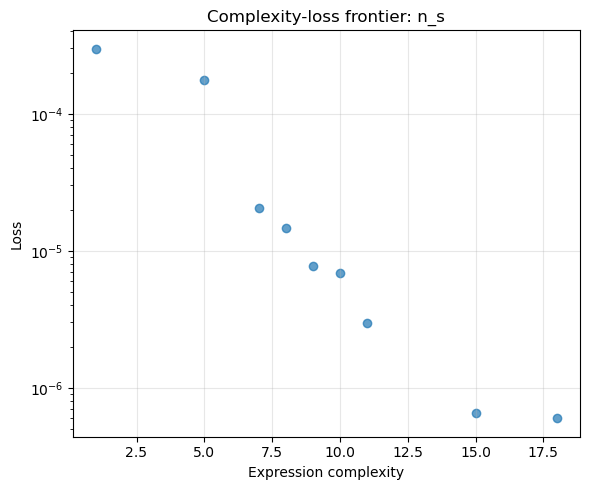

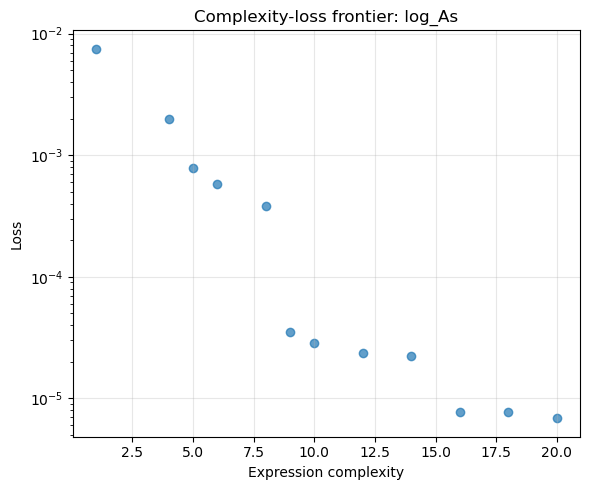

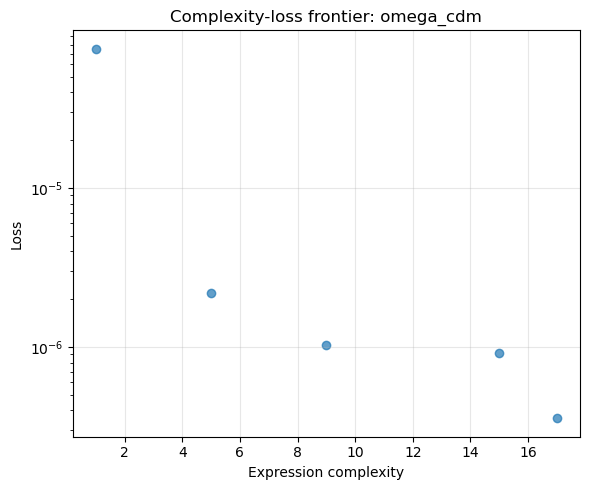

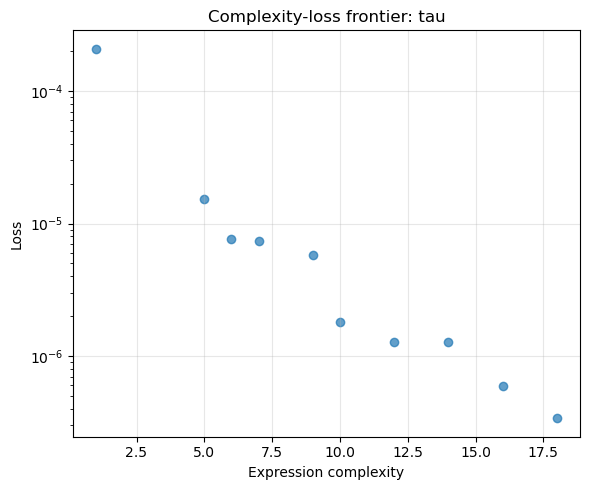

In [28]:
for param in restricted_params:
    model = joblib.load(f"pysr_restricted_model_{param}.pkl")
    eqs = model.equations_

    plt.figure(figsize=(6, 5))
    plt.scatter(eqs["complexity"], eqs["loss"], alpha=0.7)
    plt.yscale("log")
    plt.xlabel("Expression complexity")
    plt.ylabel("Loss")
    plt.title(f"Complexity-loss frontier: {param}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"figures_AA/complexity_frontier_{param}.pdf", bbox_inches="tight")
    plt.show()

    eqs.to_csv(f"results/complexity_frontier_{param}.csv", index=False)

In [29]:
import os
import pandas as pd

result_files = [
    "results/bootstrap/bootstrap_uq_summary.csv",
    "results/bootstrap/calibration_summary.csv",
    "results/noise/noise_robustness_summary.csv",
    "results/robustness/seed_sensitivity_summary.csv",
    "results/robustness/kfold_cv_summary.csv",
    "results/ablation_features/feature_ablation_summary.csv",
    "results/ablation_ell/ell_ablation_summary.csv",
    "results/ablation_operators/operator_ablation_summary.csv",
    "results/ablation_features/omega_b_feature_ablation.csv",
    "results/baselines/baseline_model_comparison.csv",
    "results/interpretability/perturbation_tests.csv",
]

for f in result_files:
    print(f"{f:70s}", os.path.exists(f))

for f in result_files:
    print("\n" + "="*80)
    print(f)
    print("="*80)
    print(pd.read_csv(f).head(40))

results/bootstrap/bootstrap_uq_summary.csv                             True
results/bootstrap/calibration_summary.csv                              True
results/noise/noise_robustness_summary.csv                             True
results/robustness/seed_sensitivity_summary.csv                        True
results/robustness/kfold_cv_summary.csv                                True
results/ablation_features/feature_ablation_summary.csv                 True
results/ablation_ell/ell_ablation_summary.csv                          True
results/ablation_operators/operator_ablation_summary.csv               True
results/ablation_features/omega_b_feature_ablation.csv                 True
results/baselines/baseline_model_comparison.csv                        True
results/interpretability/perturbation_tests.csv                        True

results/bootstrap/bootstrap_uq_summary.csv
   parameter  N_bootstrap  R2_mean_prediction  MAE_mean_prediction  \
0        n_s           20            0.994161     

# 1. Noise robustness figure

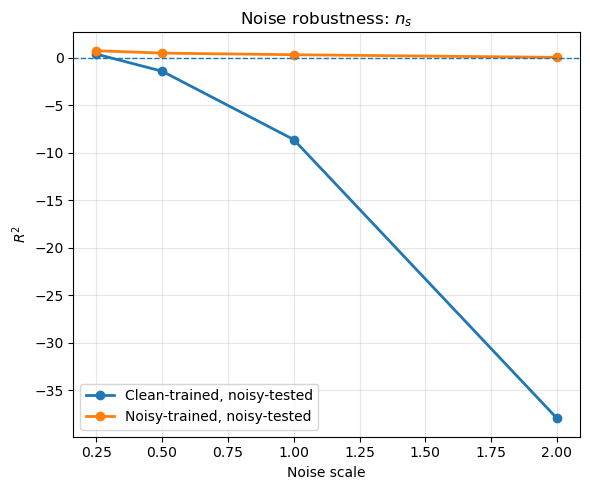

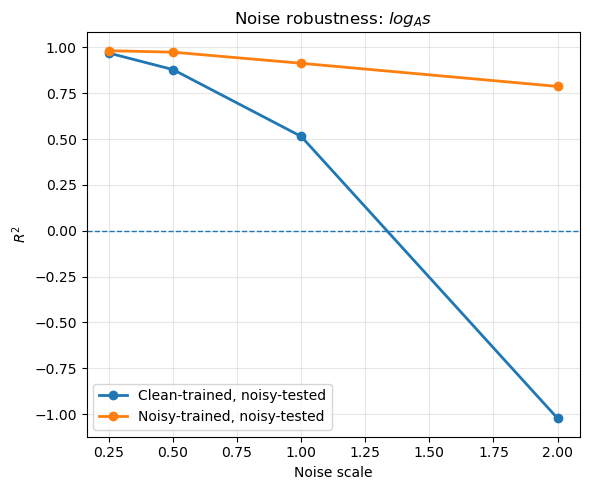

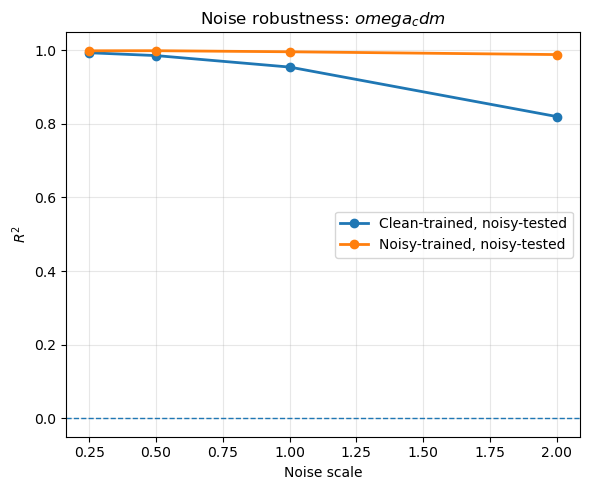

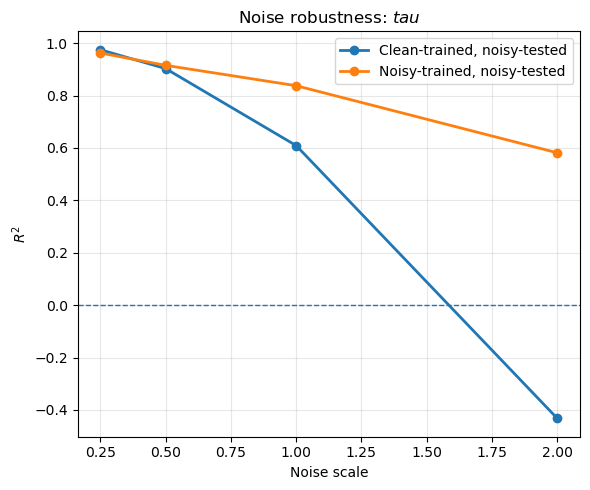

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

noise_df = pd.read_csv("results/noise/noise_robustness_summary.csv")

for param in noise_df["parameter"].unique():
    plt.figure(figsize=(6, 5))

    for setting in ["clean_train_noisy_test", "noisy_train_noisy_test"]:
        sub = noise_df[
            (noise_df["parameter"] == param) &
            (noise_df["setting"] == setting)
        ]

        label = {
            "clean_train_noisy_test": "Clean-trained, noisy-tested",
            "noisy_train_noisy_test": "Noisy-trained, noisy-tested",
        }[setting]

        plt.plot(sub["noise_scale"], sub["R2"], marker="o", linewidth=2, label=label)

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Noise scale")
    plt.ylabel(r"$R^2$")
    plt.title(rf"Noise robustness: ${param}$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"figures_AA/noise_robustness_{param}.pdf", bbox_inches="tight")
    plt.show()

# 2. Feature ablation heatmap

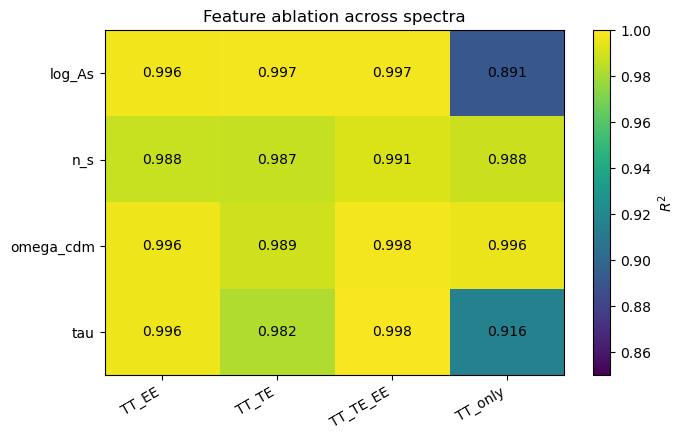

In [31]:
import numpy as np

feature_df = pd.read_csv("results/ablation_features/feature_ablation_summary.csv")
pivot = feature_df.pivot(index="parameter", columns="feature_set", values="R2")

plt.figure(figsize=(7, 4.5))
im = plt.imshow(pivot.values, aspect="auto", vmin=0.85, vmax=1.0)
plt.colorbar(im, label=r"$R^2$")

plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=30, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, f"{pivot.values[i,j]:.3f}", ha="center", va="center")

plt.title("Feature ablation across spectra")
plt.tight_layout()
plt.savefig("figures_AA/feature_ablation_heatmap.pdf", bbox_inches="tight")
plt.show()

# 3. Operator ablation figure

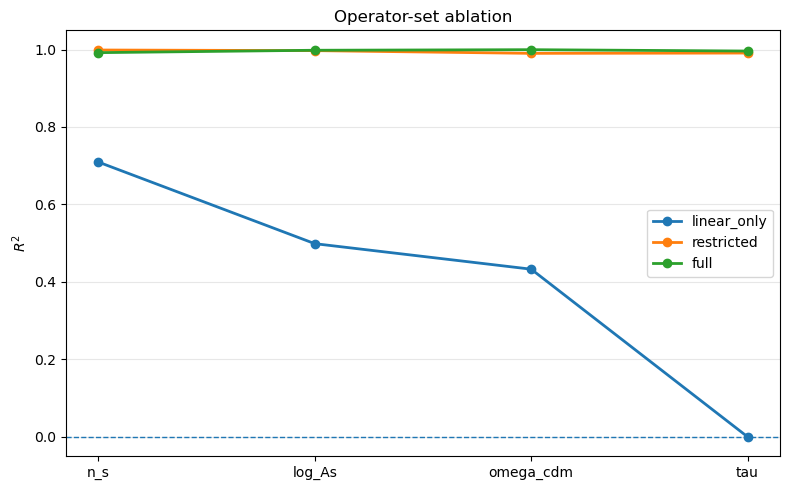

In [32]:
op_df = pd.read_csv("results/ablation_operators/operator_ablation_summary.csv")

params = ["n_s", "log_As", "omega_cdm", "tau"]
operators = ["linear_only", "restricted", "full"]

plt.figure(figsize=(8, 5))

for op in operators:
    sub = op_df[op_df["operator_set"] == op]
    yvals = [sub[sub["parameter"] == p]["R2"].values[0] for p in params]
    plt.plot(params, yvals, marker="o", linewidth=2, label=op)

plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel(r"$R^2$")
plt.title("Operator-set ablation")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("figures_AA/operator_ablation_r2.pdf", bbox_inches="tight")
plt.show()

# 4. Baseline comparison figure

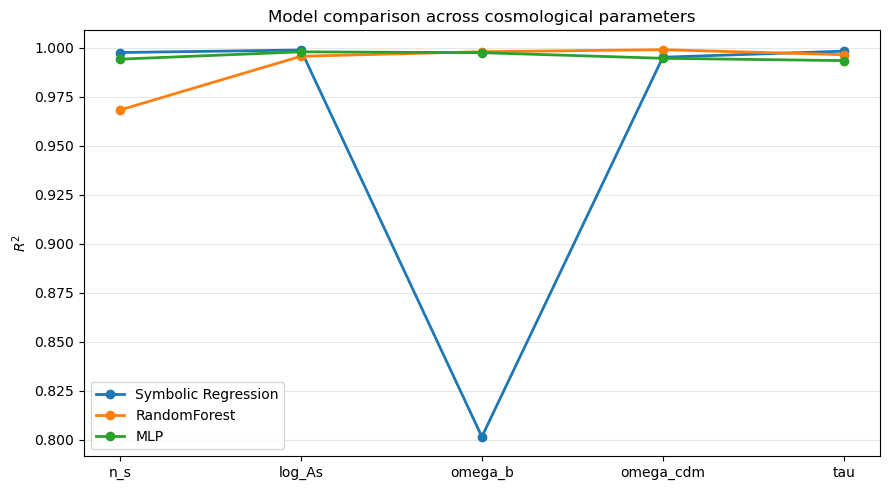

In [33]:
baseline_df = pd.read_csv("results/baselines/baseline_model_comparison.csv")

# Add main SR values manually from final symbolic-regression summary
sr_rows = [
    {"model": "Symbolic Regression", "parameter": "n_s", "R2": 0.997668, "MAE": 0.000654},
    {"model": "Symbolic Regression", "parameter": "log_As", "R2": 0.998938, "MAE": 0.002268},
    {"model": "Symbolic Regression", "parameter": "omega_b", "R2": 0.801570, "MAE": 0.000437},
    {"model": "Symbolic Regression", "parameter": "omega_cdm", "R2": 0.995267, "MAE": 0.000440},
    {"model": "Symbolic Regression", "parameter": "tau", "R2": 0.998365, "MAE": 0.000458},
]

comparison_df = pd.concat([baseline_df, pd.DataFrame(sr_rows)], ignore_index=True)

params = ["n_s", "log_As", "omega_b", "omega_cdm", "tau"]
models = ["Symbolic Regression", "RandomForest", "MLP"]

plt.figure(figsize=(9, 5))

for model in models:
    sub = comparison_df[comparison_df["model"] == model]
    yvals = [sub[sub["parameter"] == p]["R2"].values[0] for p in params]
    plt.plot(params, yvals, marker="o", linewidth=2, label=model)

plt.ylabel(r"$R^2$")
plt.title("Model comparison across cosmological parameters")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("figures_AA/model_comparison_r2.pdf", bbox_inches="tight")
plt.show()

# 5. Bootstrap uncertainty / calibration summary plot

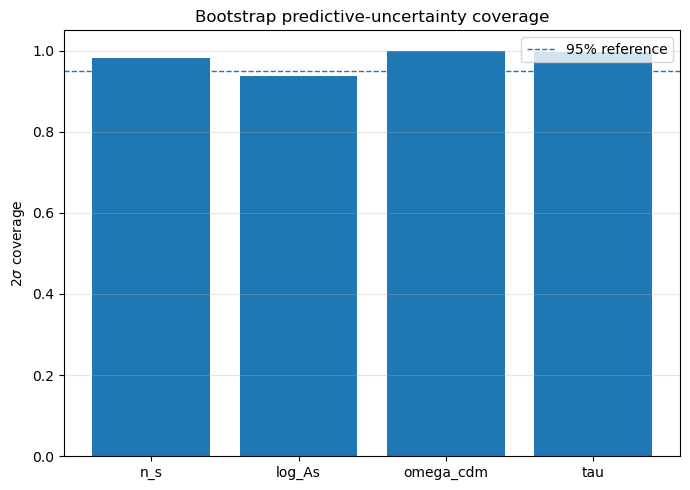

In [34]:
uq_df = pd.read_csv("results/bootstrap/bootstrap_uq_summary.csv")

plt.figure(figsize=(7, 5))
plt.bar(uq_df["parameter"], uq_df["coverage_2sigma"])
plt.axhline(0.95, linestyle="--", linewidth=1, label="95% reference")
plt.ylabel(r"2$\sigma$ coverage")
plt.title("Bootstrap predictive-uncertainty coverage")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("figures_AA/bootstrap_coverage.pdf", bbox_inches="tight")
plt.show()

# 6. Interpretability perturbation heatmap

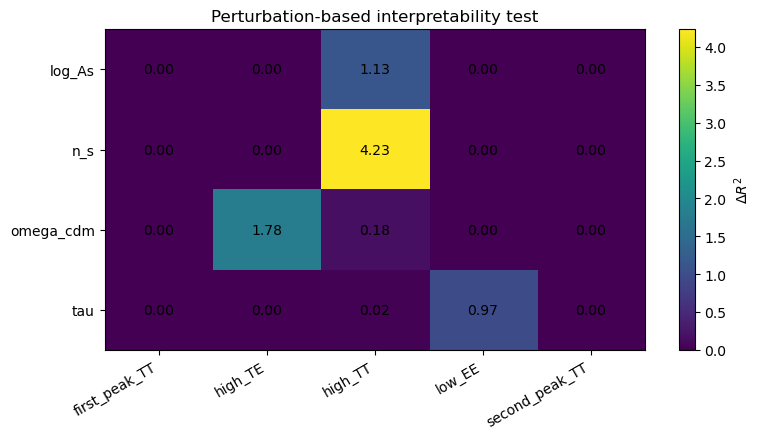

In [35]:
perturb_df = pd.read_csv("results/interpretability/perturbation_tests.csv")
pivot = perturb_df.pivot(index="parameter", columns="region", values="delta_R2")

plt.figure(figsize=(8, 4.5))
im = plt.imshow(pivot.values, aspect="auto")
plt.colorbar(im, label=r"$\Delta R^2$")

plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=30, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, f"{pivot.values[i,j]:.2f}", ha="center", va="center")

plt.title("Perturbation-based interpretability test")
plt.tight_layout()
plt.savefig("figures_AA/perturbation_heatmap.pdf", bbox_inches="tight")
plt.show()

# Manuscript Figures

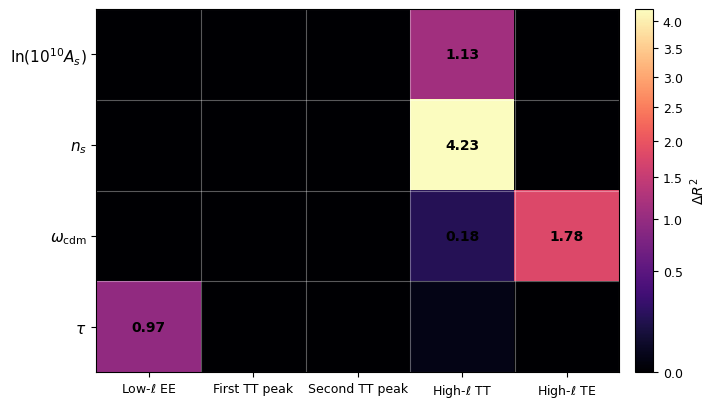

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# ------------------------------------------------------------
# Load perturbation results
# ------------------------------------------------------------
perturb_df = pd.read_csv("results/interpretability/perturbation_tests.csv")

pivot = perturb_df.pivot(
    index="parameter",
    columns="region",
    values="delta_R2"
)

# ------------------------------------------------------------
# Publication-quality ordering and labels
# ------------------------------------------------------------
row_order = ["log_As", "n_s", "omega_cdm", "tau"]

col_order = [
    "low_EE",
    "first_peak_TT",
    "second_peak_TT",
    "high_TT",
    "high_TE",
]

pivot = pivot.loc[row_order, col_order]

row_labels = [
    r"$\ln(10^{10}A_s)$",
    r"$n_s$",
    r"$\omega_{\rm cdm}$",
    r"$\tau$",
]

col_labels = [
    r"Low-$\ell$ EE",
    r"First TT peak",
    r"Second TT peak",
    r"High-$\ell$ TT",
    r"High-$\ell$ TE",
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# PowerNorm improves visibility of intermediate values
im = ax.imshow(
    pivot.values,
    aspect="auto",
    cmap="magma",
    norm=PowerNorm(gamma=0.6, vmin=0, vmax=np.nanmax(pivot.values))
)

cbar = fig.colorbar(im, ax=ax, pad=0.025)
cbar.set_label(r"$\Delta R^2$", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Axis labels
ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))

ax.set_xticklabels(col_labels, rotation=0, ha="center", fontsize=9)
ax.set_yticklabels(row_labels, fontsize=11)

# Annotate only meaningful cells
threshold = 0.10

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        value = pivot.values[i, j]
        if value >= threshold:
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color="black",
                fontweight="bold"
            )

# Subtle grid lines for readability
ax.set_xticks(np.arange(-0.5, len(col_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8, alpha=0.35)
ax.tick_params(which="minor", bottom=False, left=False)

# Improved title
# No internal title; caption carries the interpretation.


# Clean frame
for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()

plt.savefig(
    "figures_AA/perturbation_heatmap_final.pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()

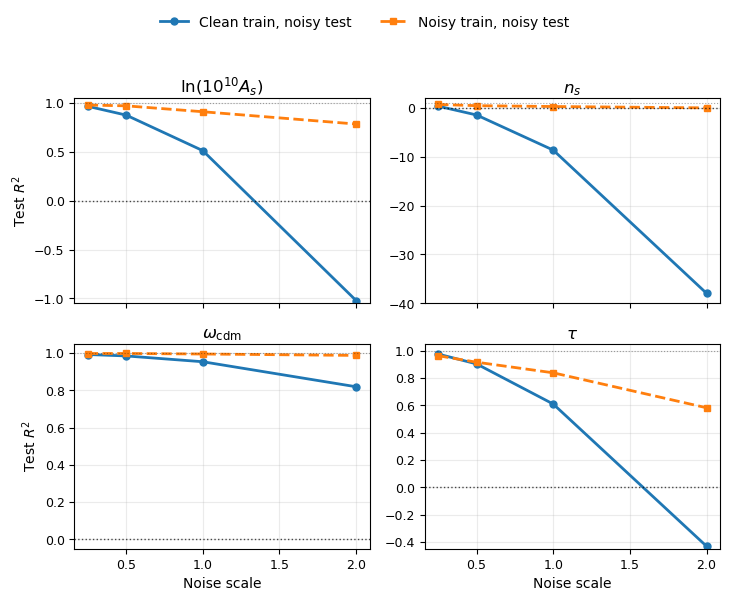

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
noise_df = pd.read_csv("results/noise/noise_robustness_summary.csv")

# ------------------------------------------------------------
# Publication labels and ordering
# ------------------------------------------------------------
param_order = ["log_As", "n_s", "omega_cdm", "tau"]

param_labels = {
    "log_As": r"$\ln(10^{10}A_s)$",
    "n_s": r"$n_s$",
    "omega_cdm": r"$\omega_{\rm cdm}$",
    "tau": r"$\tau$",
}

setting_labels = {
    "clean_train_noisy_test": "Clean train, noisy test",
    "noisy_train_noisy_test": "Noisy train, noisy test",
}

setting_styles = {
    "clean_train_noisy_test": {
        "marker": "o",
        "linestyle": "-",
        "linewidth": 2.0,
        "markersize": 5,
    },
    "noisy_train_noisy_test": {
        "marker": "s",
        "linestyle": "--",
        "linewidth": 2.0,
        "markersize": 5,
    },
}

# ------------------------------------------------------------
# Create 2x2 multi-panel figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(7.4, 5.8),
    sharex=True
)

axes = axes.flatten()

for ax, param in zip(axes, param_order):
    for setting in ["clean_train_noisy_test", "noisy_train_noisy_test"]:
        sub = noise_df[
            (noise_df["parameter"] == param) &
            (noise_df["setting"] == setting)
        ].sort_values("noise_scale")

        ax.plot(
            sub["noise_scale"],
            sub["R2"],
            label=setting_labels[setting],
            **setting_styles[setting],
        )

    # Reference lines
    ax.axhline(0, linestyle=":", linewidth=1.0, color="black", alpha=0.7)
    ax.axhline(1, linestyle=":", linewidth=0.8, color="black", alpha=0.35)

    # Panel title
    ax.set_title(param_labels[param], fontsize=12, pad=4)

    # Grid and styling
    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.tick_params(axis="both", labelsize=9)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------
for ax in axes[2:]:
    ax.set_xlabel("Noise scale", fontsize=10)

for ax in axes[::2]:
    ax.set_ylabel(r"Test $R^2$", fontsize=10)

# ------------------------------------------------------------
# Optional: panel-specific y-axis limits
# These preserve the severe degradation in n_s without compressing all panels.
# ------------------------------------------------------------
ylims = {
    "log_As": (-1.05, 1.05),
    "n_s": (-40, 2),          # keep automatic because degradation is very large
    "omega_cdm": (-0.05, 1.05),
    "tau": (-0.45, 1.05),
}

for ax, param in zip(axes, param_order):
    if ylims[param] is not None:
        ax.set_ylim(*ylims[param])

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.04),
)

# ------------------------------------------------------------
# Layout and save
# ------------------------------------------------------------
fig.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig(
    "figures_AA/noise_robustness_combined.pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()

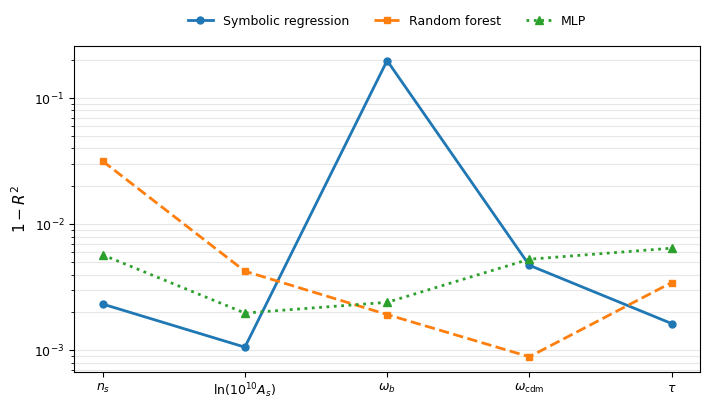

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load baseline results
# ------------------------------------------------------------
baseline_df = pd.read_csv("results/baselines/baseline_model_comparison.csv")

# Add final symbolic-regression values
sr_rows = [
    {"model": "Symbolic Regression", "parameter": "n_s", "R2": 0.997668, "MAE": 0.000654},
    {"model": "Symbolic Regression", "parameter": "log_As", "R2": 0.998938, "MAE": 0.002268},
    {"model": "Symbolic Regression", "parameter": "omega_b", "R2": 0.801570, "MAE": 0.000437},
    {"model": "Symbolic Regression", "parameter": "omega_cdm", "R2": 0.995267, "MAE": 0.000440},
    {"model": "Symbolic Regression", "parameter": "tau", "R2": 0.998365, "MAE": 0.000458},
]

comparison_df = pd.concat([baseline_df, pd.DataFrame(sr_rows)], ignore_index=True)

# ------------------------------------------------------------
# Ordering and labels
# ------------------------------------------------------------
params = ["n_s", "log_As", "omega_b", "omega_cdm", "tau"]
models = ["Symbolic Regression", "RandomForest", "MLP"]

param_labels = {
    "n_s": r"$n_s$",
    "log_As": r"$\ln(10^{10}A_s)$",
    "omega_b": r"$\omega_b$",
    "omega_cdm": r"$\omega_{\rm cdm}$",
    "tau": r"$\tau$",
}

model_labels = {
    "Symbolic Regression": "Symbolic regression",
    "RandomForest": "Random forest",
    "MLP": "MLP",
}

styles = {
    "Symbolic Regression": {"marker": "o", "linestyle": "-", "linewidth": 2.0, "markersize": 5},
    "RandomForest": {"marker": "s", "linestyle": "--", "linewidth": 2.0, "markersize": 5},
    "MLP": {"marker": "^", "linestyle": ":", "linewidth": 2.0, "markersize": 6},
}

# ------------------------------------------------------------
# Plot unexplained variance fraction: 1 - R^2
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.2))

for model in models:
    sub = comparison_df[comparison_df["model"] == model]

    residual_variance = []
    for p in params:
        r2 = sub[sub["parameter"] == p]["R2"].values[0]
        residual_variance.append(max(1.0 - r2, 1e-6))

    ax.plot(
        range(len(params)),
        residual_variance,
        label=model_labels[model],
        **styles[model],
    )

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------
ax.set_yscale("log")
ax.set_ylabel(r"$1-R^2$", fontsize=11)

ax.set_xticks(range(len(params)))
ax.set_xticklabels([param_labels[p] for p in params], fontsize=10)

ax.grid(True, which="both", axis="y", alpha=0.3, linewidth=0.8)
ax.tick_params(axis="both", labelsize=9)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

# No internal title; use caption instead.
ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.13))

plt.tight_layout()

plt.savefig(
    "figures_AA/model_comparison_unexplained_variance.pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()

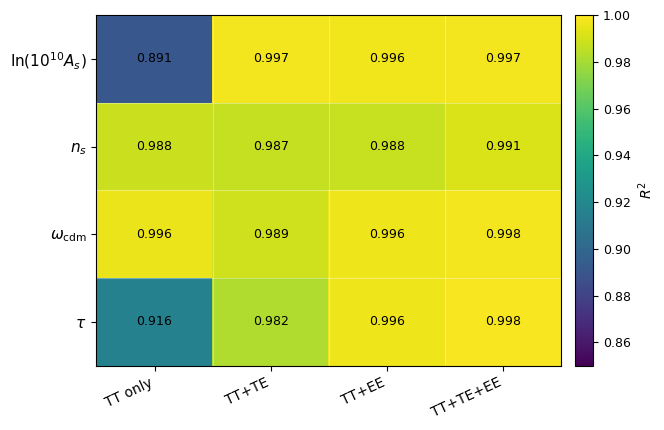

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load feature ablation results
# ------------------------------------------------------------
feature_df = pd.read_csv("results/ablation_features/feature_ablation_summary.csv")

pivot = feature_df.pivot(
    index="parameter",
    columns="feature_set",
    values="R2"
)

# ------------------------------------------------------------
# Publication ordering and labels
# ------------------------------------------------------------
row_order = ["log_As", "n_s", "omega_cdm", "tau"]
col_order = ["TT_only", "TT_TE", "TT_EE", "TT_TE_EE"]

pivot = pivot.loc[row_order, col_order]

row_labels = [
    r"$\ln(10^{10}A_s)$",
    r"$n_s$",
    r"$\omega_{\rm cdm}$",
    r"$\tau$",
]

col_labels = [
    "TT only",
    "TT+TE",
    "TT+EE",
    "TT+TE+EE",
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.8, 4.4))

im = ax.imshow(
    pivot.values,
    aspect="auto",
    vmin=0.85,
    vmax=1.0,
    cmap="viridis"
)

cbar = fig.colorbar(im, ax=ax, pad=0.025)
cbar.set_label(r"$R^2$", fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))

ax.set_xticklabels(col_labels, rotation=25, ha="right", fontsize=10)
ax.set_yticklabels(row_labels, fontsize=11)

# Annotate all cells because values are close and differences matter
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(
            j,
            i,
            f"{pivot.values[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

# Subtle grid
ax.set_xticks(np.arange(-0.5, len(col_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8, alpha=0.35)
ax.tick_params(which="minor", bottom=False, left=False)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

# No internal title; use caption instead.
plt.tight_layout()

plt.savefig(
    "figures_AA/feature_ablation_heatmap_final.pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()

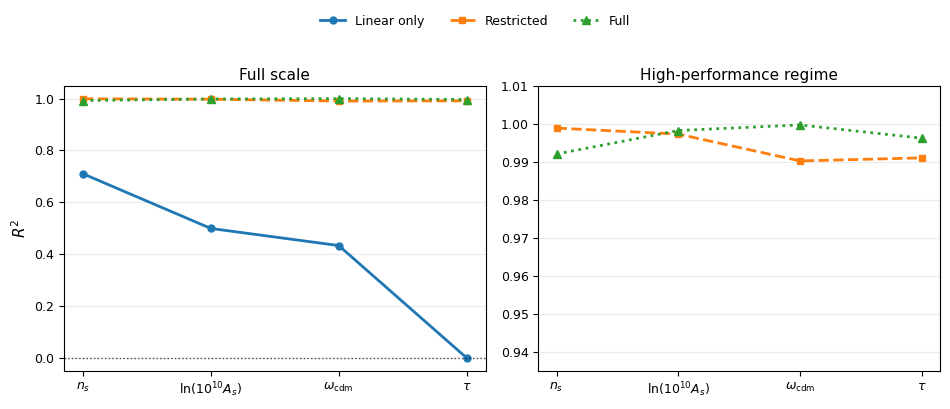

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
op_df = pd.read_csv("results/ablation_operators/operator_ablation_summary.csv")

# ------------------------------------------------------------
# Ordering and labels
# ------------------------------------------------------------
params = ["n_s", "log_As", "omega_cdm", "tau"]
operators = ["linear_only", "restricted", "full"]

param_labels = {
    "n_s": r"$n_s$",
    "log_As": r"$\ln(10^{10}A_s)$",
    "omega_cdm": r"$\omega_{\rm cdm}$",
    "tau": r"$\tau$",
}

operator_labels = {
    "linear_only": "Linear only",
    "restricted": "Restricted",
    "full": "Full",
}

styles = {
    "linear_only": {"marker": "o", "linestyle": "-", "linewidth": 2.0, "markersize": 5},
    "restricted": {"marker": "s", "linestyle": "--", "linewidth": 2.0, "markersize": 5},
    "full": {"marker": "^", "linestyle": ":", "linewidth": 2.0, "markersize": 6},
}

# ------------------------------------------------------------
# Build figure: full scale + zoomed scale
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(9.6, 3.8),
    sharex=True,
    gridspec_kw={"width_ratios": [1.05, 1.0]}
)

for ax in axes:
    for op in operators:
        sub = op_df[op_df["operator_set"] == op]

        yvals = [
            sub[sub["parameter"] == p]["R2"].values[0]
            for p in params
        ]

        ax.plot(
            range(len(params)),
            yvals,
            label=operator_labels[op],
            **styles[op],
        )

    ax.axhline(0, linestyle=":", linewidth=1.0, color="black", alpha=0.7)
    ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
    ax.set_xticks(range(len(params)))
    ax.set_xticklabels([param_labels[p] for p in params], fontsize=9)
    ax.tick_params(axis="both", labelsize=9)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

# Left panel: full range
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_ylabel(r"$R^2$", fontsize=11)
axes[0].set_title("Full scale", fontsize=11, pad=4)

# Right panel: zoomed high-performance regime
axes[1].set_ylim(0.935, 1.01)
axes[1].set_title("High-performance regime", fontsize=11, pad=4)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.08),
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "figures_AA/operator_ablation_r2_final.pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()

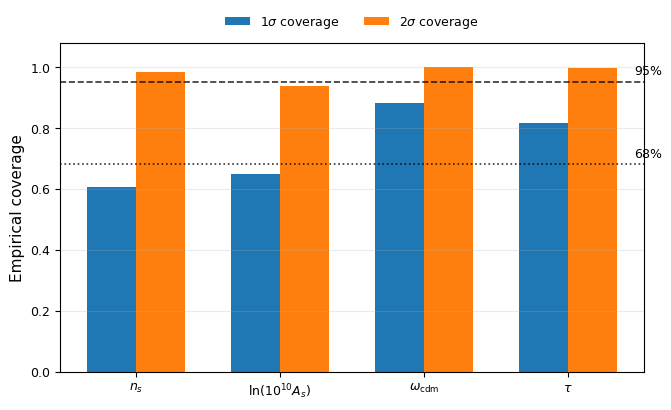

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load bootstrap uncertainty summary
# ------------------------------------------------------------
uq_df = pd.read_csv("results/bootstrap/bootstrap_uq_summary.csv")

# ------------------------------------------------------------
# Ordering and labels
# ------------------------------------------------------------
param_order = ["n_s", "log_As", "omega_cdm", "tau"]

param_labels = {
    "n_s": r"$n_s$",
    "log_As": r"$\ln(10^{10}A_s)$",
    "omega_cdm": r"$\omega_{\rm cdm}$",
    "tau": r"$\tau$",
}

uq_df = uq_df.set_index("parameter").loc[param_order].reset_index()

x = np.arange(len(param_order))
width = 0.34

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.8, 4.2))

ax.bar(
    x - width / 2,
    uq_df["coverage_1sigma"],
    width,
    label=r"$1\sigma$ coverage",
)

ax.bar(
    x + width / 2,
    uq_df["coverage_2sigma"],
    width,
    label=r"$2\sigma$ coverage",
)

# Reference lines
ax.axhline(0.68, linestyle=":", linewidth=1.2, color="black", alpha=0.8)
ax.axhline(0.95, linestyle="--", linewidth=1.2, color="black", alpha=0.8)

ax.text(
    len(param_order) - 0.35,
    0.68 + 0.015,
    r"68%",
    ha="right",
    va="bottom",
    fontsize=9,
)

ax.text(
    len(param_order) - 0.35,
    0.95 + 0.015,
    r"95%",
    ha="right",
    va="bottom",
    fontsize=9,
)

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels([param_labels[p] for p in param_order], fontsize=10)

ax.set_ylabel("Empirical coverage", fontsize=11)
ax.set_ylim(0, 1.08)

ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.tick_params(axis="both", labelsize=9)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

# No title; caption carries the interpretation
ax.legend(
    frameon=False,
    fontsize=9,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
)

plt.tight_layout()

plt.savefig(
    "figures_AA/bootstrap_coverage_final.pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

# Appendix Figures

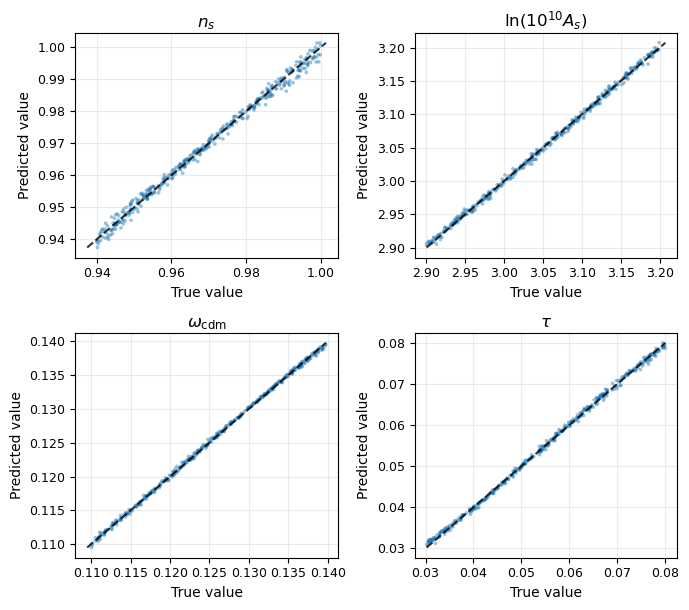

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Parameters and labels
# ------------------------------------------------------------
params = ["n_s", "log_As", "omega_cdm", "tau"]

param_labels = {
    "n_s": r"$n_s$",
    "log_As": r"$\ln(10^{10}A_s)$",
    "omega_cdm": r"$\omega_{\rm cdm}$",
    "tau": r"$\tau$",
}

# ------------------------------------------------------------
# Create 2x2 appendix figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(7.0, 6.2)
)

axes = axes.flatten()

for ax, param in zip(axes, params):

    data = np.load(f"results/bootstrap/bootstrap_predictions_{param}.npz")

    y_true = data["y_true"]
    pred_mean = data["pred_mean"]

    order = np.argsort(y_true)

    x = y_true[order]
    y = pred_mean[order]

    # --------------------------------------------------------
    # Predicted vs true scatter
    # --------------------------------------------------------
    ax.scatter(
        x,
        y,
        s=7,
        alpha=0.45,
        edgecolors="none",
    )

    # --------------------------------------------------------
    # y = x reference line
    # --------------------------------------------------------
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        linewidth=1.5,
        color="black",
        alpha=0.8,
    )

    # --------------------------------------------------------
    # Panel formatting
    # --------------------------------------------------------
    ax.set_title(param_labels[param], fontsize=12, pad=4)

    ax.set_xlabel("True value", fontsize=10)
    ax.set_ylabel("Predicted value", fontsize=10)

    ax.grid(True, alpha=0.25, linewidth=0.8)

    ax.tick_params(axis="both", labelsize=9)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
fig.tight_layout()

plt.savefig(
    "figures_AA/bootstrap_pred_vs_true_combined_final.pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()

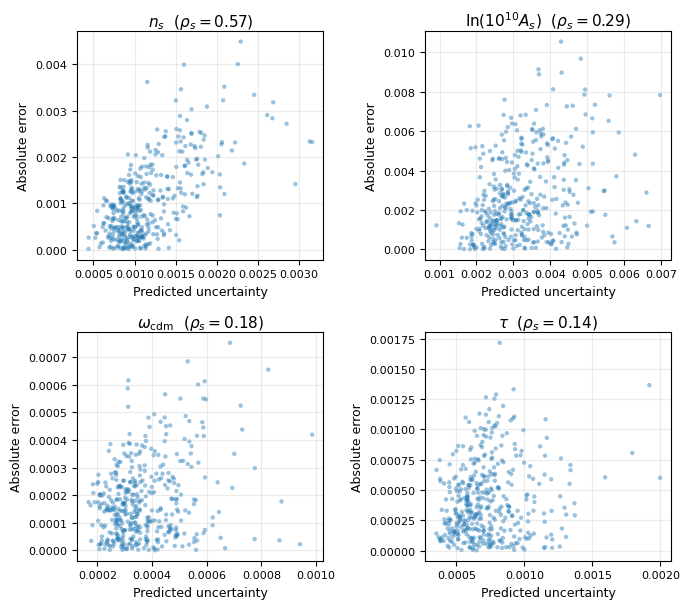

   parameter  spearman_uncertainty_error       p_value  mean_abs_error  \
0        n_s                    0.568460  1.297551e-35        0.001054   
1     log_As                    0.293712  2.118696e-09        0.002665   
2  omega_cdm                    0.176894  3.781591e-04        0.000181   
3        tau                    0.143080  4.138571e-03        0.000416   

   mean_pred_std  
0       0.001162  
1       0.003229  
2       0.000372  
3       0.000729  


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

params = ["n_s", "log_As", "omega_cdm", "tau"]

param_labels = {
    "n_s": r"$n_s$",
    "log_As": r"$\ln(10^{10}A_s)$",
    "omega_cdm": r"$\omega_{\rm cdm}$",
    "tau": r"$\tau$",
}

calibration_rows = []

fig, axes = plt.subplots(2, 2, figsize=(7.0, 6.2))
axes = axes.flatten()

for ax, param in zip(axes, params):
    data = np.load(f"results/bootstrap/bootstrap_predictions_{param}.npz")

    y_true = data["y_true"]
    pred_mean = data["pred_mean"]
    pred_std = data["pred_std"]

    abs_error = np.abs(y_true - pred_mean)
    rho, pval = spearmanr(pred_std, abs_error)

    calibration_rows.append({
        "parameter": param,
        "spearman_uncertainty_error": rho,
        "p_value": pval,
        "mean_abs_error": abs_error.mean(),
        "mean_pred_std": pred_std.mean(),
    })

    ax.scatter(
        pred_std,
        abs_error,
        s=10,
        alpha=0.45,
        edgecolors="none",
    )

    ax.set_title(
        rf"{param_labels[param]}  ($\rho_s={rho:.2f}$)",
        fontsize=11,
        pad=4,
    )

    ax.set_xlabel("Predicted uncertainty", fontsize=9)
    ax.set_ylabel("Absolute error", fontsize=9)

    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.tick_params(axis="both", labelsize=8)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

fig.tight_layout()

plt.savefig(
    "figures_AA/calibration_combined_final.pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

calibration_df = pd.DataFrame(calibration_rows)
calibration_df.to_csv("results/bootstrap/calibration_summary.csv", index=False)
print(calibration_df)

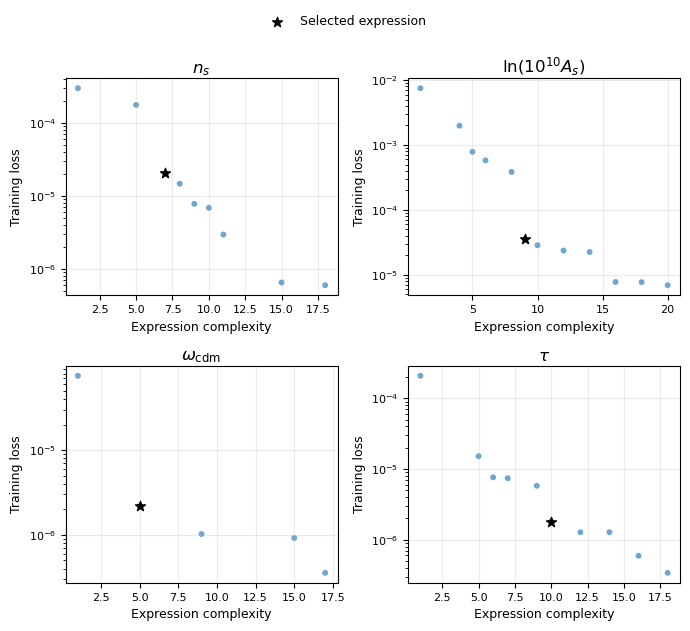

In [73]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

params = ["n_s", "log_As", "omega_cdm", "tau"]

param_labels = {
    "n_s": r"$n_s$",
    "log_As": r"$\ln(10^{10}A_s)$",
    "omega_cdm": r"$\omega_{\rm cdm}$",
    "tau": r"$\tau$",
}

fig, axes = plt.subplots(2, 2, figsize=(7.0, 6.2))
axes = axes.flatten()

for ax, param in zip(axes, params):
    model = joblib.load(f"pysr_restricted_model_{param}.pkl")
    eqs = model.equations_

    ax.scatter(
        eqs["complexity"],
        eqs["loss"],
        s=18,
        alpha=0.65,
        edgecolors="none",
    )

    # Highlight best equation if the relevant column exists
    if "score" in eqs.columns:
        best_idx = eqs["score"].idxmax()
    else:
        best_idx = eqs["loss"].idxmin()

    ax.scatter(
        eqs.loc[best_idx, "complexity"],
        eqs.loc[best_idx, "loss"],
        s=55,
        marker="*",
        color="black",
        label="Selected expression",
        zorder=5,
    )

    ax.set_yscale("log")
    ax.set_title(param_labels[param], fontsize=12, pad=4)
    ax.set_xlabel("Expression complexity", fontsize=9)
    ax.set_ylabel("Training loss", fontsize=9)

    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.tick_params(axis="both", labelsize=8)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.02),
)

fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "figures_AA/complexity_frontier_combined_final.pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

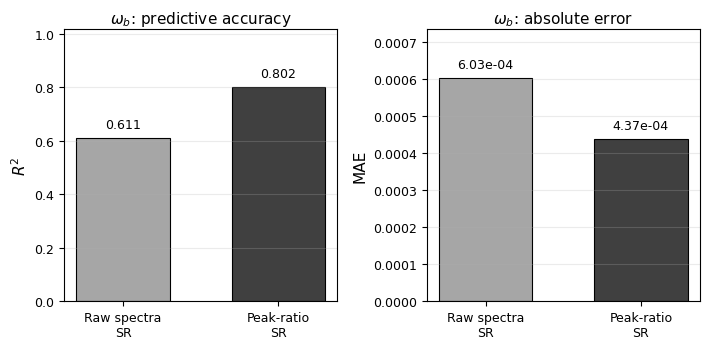

In [77]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures_AA", exist_ok=True)

# ------------------------------------------------------------
# Load final symbolic-regression summary from original notebook
# ------------------------------------------------------------
summary_df = pd.read_csv("final_symbolic_regression_summary.csv")

# ------------------------------------------------------------
# Select omega_b raw vs engineered results
# ------------------------------------------------------------
method_order = ["Full SR", "Engineered SR"]

omega_b_df = summary_df[
    (summary_df["parameter"] == "omega_b") &
    (summary_df["method"].isin(method_order))
].set_index("method").loc[method_order]

x = np.arange(len(method_order))

method_labels = [
    "Raw spectra\nSR",
    "Peak-ratio\nSR",
]

colors = ["0.65", "0.25"]

# ------------------------------------------------------------
# Combined appendix figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.6))

# Panel A: R2
axes[0].bar(
    x,
    omega_b_df["R2"].values,
    width=0.6,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(method_labels, fontsize=9)
axes[0].set_ylabel(r"$R^2$", fontsize=11)
axes[0].set_ylim(0, 1.02)
axes[0].grid(True, axis="y", alpha=0.25, linewidth=0.8)
axes[0].set_title(r"$\omega_b$: predictive accuracy", fontsize=11, pad=4)

for i, val in enumerate(omega_b_df["R2"].values):
    axes[0].text(
        i,
        val + 0.025,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Panel B: MAE
axes[1].bar(
    x,
    omega_b_df["MAE"].values,
    width=0.6,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(method_labels, fontsize=9)
axes[1].set_ylabel("MAE", fontsize=11)
axes[1].grid(True, axis="y", alpha=0.25, linewidth=0.8)
axes[1].set_title(r"$\omega_b$: absolute error", fontsize=11, pad=4)

ymax = omega_b_df["MAE"].max()
axes[1].set_ylim(0, ymax * 1.22)

for i, val in enumerate(omega_b_df["MAE"].values):
    axes[1].text(
        i,
        val + ymax * 0.03,
        f"{val:.2e}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Styling
for ax in axes:
    ax.tick_params(axis="both", labelsize=9)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

fig.tight_layout()

fig.savefig(
    "figures_AA/omega_b_engineering_summary_final.pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

In [78]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Load existing robustness summaries
# ------------------------------------------------------------
seed_df = pd.read_csv("results/robustness/seed_sensitivity_summary.csv")
cv_df = pd.read_csv("results/robustness/kfold_cv_summary.csv")

param_order = ["n_s", "log_As", "omega_cdm", "tau"]

param_labels = {
    "n_s": r"$n_s$",
    "log_As": r"$\ln(10^{10}A_s)$",
    "omega_cdm": r"$\omega_{\rm cdm}$",
    "tau": r"$\tau$",
}

# ------------------------------------------------------------
# Compute mean ± std summaries
# ------------------------------------------------------------
seed_summary = (
    seed_df
    .groupby("parameter")
    .agg(
        seed_R2_mean=("R2", "mean"),
        seed_R2_std=("R2", "std"),
        seed_MAE_mean=("MAE", "mean"),
        seed_MAE_std=("MAE", "std"),
    )
)

cv_summary = (
    cv_df
    .groupby("parameter")
    .agg(
        cv_R2_mean=("R2", "mean"),
        cv_R2_std=("R2", "std"),
        cv_MAE_mean=("MAE", "mean"),
        cv_MAE_std=("MAE", "std"),
    )
)

stability_df = seed_summary.join(cv_summary).loc[param_order].reset_index()

# ------------------------------------------------------------
# Format for LaTeX
# ------------------------------------------------------------
def fmt_pm(mean, std, digits=4):
    return rf"{mean:.{digits}f} $\pm$ {std:.{digits}f}"

def fmt_sci_pm(mean, std):
    return rf"{mean:.2e} $\pm$ {std:.2e}"

latex_rows = []

for _, row in stability_df.iterrows():
    p = row["parameter"]

    latex_rows.append({
        "Parameter": param_labels[p],
        "Seed R2": fmt_pm(row["seed_R2_mean"], row["seed_R2_std"], 4),
        "Seed MAE": fmt_sci_pm(row["seed_MAE_mean"], row["seed_MAE_std"]),
        "CV R2": fmt_pm(row["cv_R2_mean"], row["cv_R2_std"], 4),
        "CV MAE": fmt_sci_pm(row["cv_MAE_mean"], row["cv_MAE_std"]),
    })

latex_df = pd.DataFrame(latex_rows)

print(latex_df.to_latex(index=False, escape=False))

stability_df.to_csv("results/robustness/symbolic_regression_stability_summary.csv", index=False)

\begin{tabular}{lllll}
\toprule
Parameter & Seed R2 & Seed MAE & CV R2 & CV MAE \\
\midrule
$n_s$ & 0.9928 $\pm$ 0.0041 & 1.12e-03 $\pm$ 3.16e-04 & 0.9869 $\pm$ 0.0083 & 1.49e-03 $\pm$ 4.83e-04 \\
$\ln(10^{10}A_s)$ & 0.9974 $\pm$ 0.0013 & 3.39e-03 $\pm$ 8.47e-04 & 0.9975 $\pm$ 0.0015 & 3.30e-03 $\pm$ 1.18e-03 \\
$\omega_{\rm cdm}$ & 0.9980 $\pm$ 0.0008 & 2.96e-04 $\pm$ 7.45e-05 & 0.9973 $\pm$ 0.0018 & 3.58e-04 $\pm$ 1.10e-04 \\
$\tau$ & 0.9962 $\pm$ 0.0028 & 6.70e-04 $\pm$ 2.48e-04 & 0.9931 $\pm$ 0.0065 & 8.21e-04 $\pm$ 4.24e-04 \\
\bottomrule
\end{tabular}

